# 📦 Creating a Brick Empire: LEGO Case Study with Python

This notebook explores predictive and prescriptive analytics for LEGO set investments using real data from 2018–2019.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pulp

In [25]:
# Load data
df = pd.read_excel("LEGO Analytics Case Data.xlsx")
df

,Set number,Name,Theme,Subtheme,Release Month,Piece Count,number of Minifigures,Length,Width,Height,Weight,US Retail Price
0,10260,Downtown Diner,Creator Expert,Modular Buildings,January,2480,6,22.8,14.8,3.9,6.55,169.99
1,10261,Roller Coaster,Creator Expert,Fairground,June,4124,11,22.9,19.1,7.3,12.78,379.99
2,10262,James Bond Aston Martin DB5,Creator Expert,Vehicles,August,1290,0,18.9,11.1,3.6,3.40,149.99
3,10263,Winter Village Fire Station,Creator Expert,Winter Village,October,1166,8,18.8,11.0,3.4,3.01,99.99
4,10268,Vestas Wind Turbine,Creator Expert,Vestas,November,826,3,14.8,18.7,4.2,4.75,199.99
...,...,...,...,...,...,...,...,...,...,...,...,...
609,76134,Spider-Man: Doc Ock Diamond Heist,Marvel Super Heroes,Juniors,January,150,3,10.3,8.7,3.0,1.17,29.99
610,76137,Batman vs The Riddler Robbery,DC Super Heroes,Juniors,August,59,2,7.5,5.6,1.8,0.25,9.99
611,76138,Batman and the Joker Escape,DC Super Heroes,Juniors,August,171,4,10.3,8.7,3.0,1.10,39.99
612,76139,1989 Batmobile,DC Super Heroes,Batman,November,3306,3,NaN,NaN,NaN,NaN,249.99


## 📊 A little Descriptive Analysis

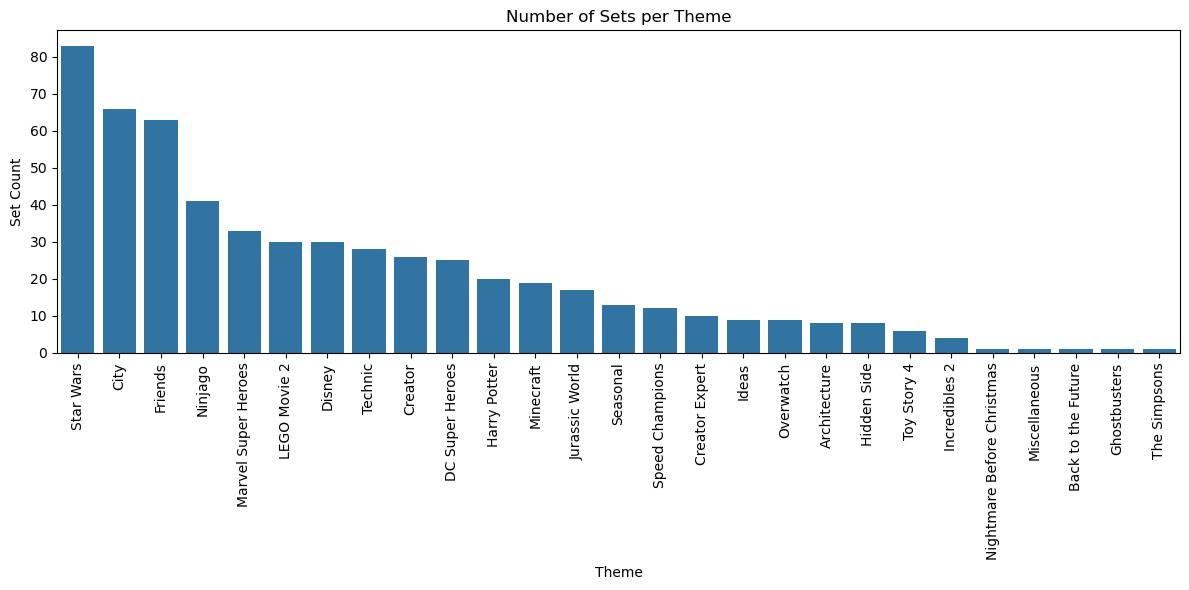

In [26]:
# Create calculated fields
df['PricePerPiece'] = df['US Retail Price'] / df['Piece Count']
df['Volume'] = df['Length'] * df['Width'] * df['Height']
df['Density'] = df['Weight'] / df['Volume']

# Filter themes and subthemes of interest
themes_of_interest = [
    'Architecture', 'City', 'Creator', 'Creator Expert', 'DC Super Heroes',
    'Disney', 'Friends', 'Harry Potter', 'Hidden Side', 'Ideas',
    'Jurassic World', 'LEGO Movie 2', 'Marvel Super Heroes', 'Minecraft',
    'Ninjago', 'Overwatch', 'Speed Champions', 'Star Wars', 'Technic'
]

subthemes_of_interest = ['Brickheadz', 'Juniors']

df_filtered = df[df['Theme'].isin(themes_of_interest) | df['Subtheme'].isin(subthemes_of_interest)]

# Aggregate statistics
theme_summary = df_filtered.groupby('Theme').agg({
    'Set number': 'count',
    'Piece Count': 'mean',
    'number of Minifigures': 'mean',
    'US Retail Price': 'mean',
    'PricePerPiece': 'mean',
    'Volume': 'mean',
    'Density': 'mean'
}).rename(columns={'Set number': 'Set Count'}).reset_index()

# Visualization: Example
plt.figure(figsize=(12, 6))
sns.barplot(x='Theme', y='Set Count', data=theme_summary.sort_values('Set Count', ascending=False))
plt.xticks(rotation=90)
plt.title('Number of Sets per Theme')
plt.tight_layout()
plt.show()


## 📈 Predictive Analysis


### 🔍 Objective
Build a regression model to estimate what LEGO sets should cost based on their features. This helps identify underpriced sets with investment potential.

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Select numeric features
df_reg = df.dropna(subset=['Piece Count', 'Weight', 'US Retail Price'])
X = df_reg[['Piece Count', 'Weight']]
y = df_reg['US Retail Price']

# Train model
model = LinearRegression()
model.fit(X, y)
print('Coefficients:', model.coef_)
print('Intercept:', model.intercept_)

# Predict prices
df_reg['Predicted Price'] = model.predict(X)
df_reg['Value Potential'] = df_reg['Predicted Price'] - df_reg['US Retail Price']
df_reg

Coefficients: [7.65182798e-03 2.34232072e+01]
Intercept: 5.636198142499829


C:\Users\pz6755\AppData\Local\Temp\ipykernel_21400\977955125.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reg['Predicted Price'] = model.predict(X)
C:\Users\pz6755\AppData\Local\Temp\ipykernel_21400\977955125.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reg['Value Potential'] = df_reg['Predicted Price'] - df_reg['US Retail Price']


,Set number,Name,Theme,Subtheme,Release Month,Piece Count,number of Minifigures,Length,Width,Height,Weight,US Retail Price,PricePerPiece,Volume,Density,Predicted Price,Value Potential
0,10260,Downtown Diner,Creator Expert,Modular Buildings,January,2480,6,22.8,14.8,3.9,6.55,169.99,0.068544,1316.016,0.004977,178.034739,8.044739
1,10261,Roller Coaster,Creator Expert,Fairground,June,4124,11,22.9,19.1,7.3,12.78,379.99,0.092141,3192.947,0.004003,336.540925,-43.449075
2,10262,James Bond Aston Martin DB5,Creator Expert,Vehicles,August,1290,0,18.9,11.1,3.6,3.40,149.99,0.116271,755.244,0.004502,95.145961,-54.844039
3,10263,Winter Village Fire Station,Creator Expert,Winter Village,October,1166,8,18.8,11.0,3.4,3.01,99.99,0.085755,703.120,0.004281,85.062083,-14.927917
4,10268,Vestas Wind Turbine,Creator Expert,Vestas,November,826,3,14.8,18.7,4.2,4.75,199.99,0.242119,1162.392,0.004086,123.216842,-76.773158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
608,76133,Spider-Man Car Chase,Marvel Super Heroes,Juniors,January,52,2,7.5,5.6,1.8,0.35,9.99,0.192115,75.600,0.004630,14.232216,4.242216
609,76134,Spider-Man: Doc Ock Diamond Heist,Marvel Super Heroes,Juniors,January,150,3,10.3,8.7,3.0,1.17,29.99,0.199933,268.830,0.004352,34.189125,4.199125
610,76137,Batman vs The Riddler Robbery,DC Super Heroes,Juniors,August,59,2,7.5,5.6,1.8,0.25,9.99,0.169322,75.600,0.003307,11.943458,1.953458
611,76138,Batman and the Joker Escape,DC Super Heroes,Juniors,August,171,4,10.3,8.7,3.0,1.10,39.99,0.233860,268.830,0.004092,32.710189,-7.279811


### 🔑 Model Used

$$ Estimated Price = 5.636198 + 0.007652 × Piece Count + 23.42321 × Weight$$

## 🧮 3. Prescriptive Analysis (Optimization)

### 🔍 Objective
Select the best combination of LEGO sets to invest in, given:

A budget limit of $4,000

A storage space limit (60" × 36" × 24")

Diversification: no theme > 20\%, and required minimums for Hidden Side, Ideas, Star Wars

At most 10 units of any single set

In [29]:
# Load investment candidates
df_inv = pd.read_excel("LEGO Analytics Optimization.xlsx")
df_inv.head()

,,Set Number,Name,Theme,Subtheme,Release Month (US),Piece Count,Weight,Volume,US Retail Price,Estimated Retail Price,Value Potential
0,2019,60206,Jet Patrol,City,Sky Police,January,54,0.32,81.840,9.99,13.544823,3.554823
1,2019,60212,Barbecue Burn Out,City,Fire,January,64,0.29,61.380,9.99,12.918645,2.928645
2,2019,60216,Downtown Fire Brigade,City,Fire,January,943,4.06,985.635,99.99,107.950093,7.960093
3,2019,60218,Desert Rally Racer,City,NaN,January,75,0.35,81.840,9.99,14.408208,4.418208
4,2019,60219,Construction Loader,City,NaN,January,88,0.34,81.840,9.99,14.273449,4.283449


### 🧠 Decision Variables
x_i = Number of units to buy of set i

### 🎯 Objective Function
Maximize total value potential:

max Σ (x_i × Value_Potential_i)

### 🧠 Constraints

Budget: Σ(x_i × Price_i) ≤ \$4000

Volume: Σ(x_i × Volume_i) ≤ 51,840 in³

Theme allocation constraints

Purchase limits

In [31]:
# Setup problem
prob = pulp.LpProblem("LEGO_Investment", pulp.LpMaximize)

# Decision variables
choices = {row['Set Number']: pulp.LpVariable(f"x_{row['Set Number']}", cat='Integer', lowBound=0, upBound=10)
           for idx, row in df_inv.iterrows()}

# Objective: Maximize total value potential
prob += pulp.lpSum(choices[row['Set Number']] * row['Value Potential'] for idx, row in df_inv.iterrows())

# Constraints
total_cost = pulp.lpSum(choices[row['Set Number']] * row['US Retail Price'] for idx, row in df_inv.iterrows())
total_volume = pulp.lpSum(choices[row['Set Number']] * row['Volume'] for idx, row in df_inv.iterrows())

prob += total_cost <= 4000, "BudgetLimit"
prob += total_volume <= 60 * 36 * 24, "StorageLimit"

# Theme diversification constraints
total_units = pulp.lpSum(choices[row['Set Number']] for idx, row in df_inv.iterrows())

for theme in df_inv['Theme'].unique():
    theme_total = pulp.lpSum(choices[row['Set Number']] for idx, row in df_inv.iterrows() if row['Theme'] == theme)
    prob += theme_total <= 0.2 * total_units, f"Max20Percent_{theme}"

# Required minimum sets from Hidden Side, Ideas, and Star Wars
for theme in ['Hidden Side', 'Ideas', 'Star Wars']:
    theme_total = pulp.lpSum(choices[row['Set Number']] for idx, row in df_inv.iterrows() if row['Theme'] == theme)
    prob += theme_total >= 0.05 * total_units, f"Min5Percent_{theme}"

# Solve
prob.solve()

# Output results
investment_plan = pd.DataFrame([
    {
        'Set Number': row['Set Number'],
        'Set Name': row['Name'],
        'Theme': row['Theme'],
        'Units Purchased': choices[row['Set Number']].varValue,
        'Price': row['US Retail Price'],
        'Total Cost': choices[row['Set Number']].varValue * row['US Retail Price'] if choices[row['Set Number']].varValue else 0,
        'Total Value Potential': choices[row['Set Number']].varValue * row['Value Potential'] if choices[row['Set Number']].varValue else 0
    }
    for idx, row in df_inv.iterrows() if choices[row['Set Number']].varValue
])



In [32]:
# Show the resulting investment plan
print(investment_plan)

# Or display in a notebook
investment_plan.head(10)

    Set Number                              Set Name                Theme  \
0        60218                    Desert Rally Racer                 City   
1        60219                   Construction Loader                 City   
2        60224             Satellite Service Mission                 City   
3        31087                            Dune Buggy              Creator   
4        31088                    Deep Sea Creatures              Creator   
5        31092                  Helicopter Adventure              Creator   
6        31095                   Fairground Carousel              Creator   
7        70422                   Shrimp Shack Attack          Hidden Side   
8        21319                          Central Perk                Ideas   
9        76133                  Spider-Man Car Chase  Marvel Super Heroes   
10       21153                         The Wool Farm            Minecraft   
11       21155                      The Creeper Mine            Minecraft   

,Set Number,Set Name,Theme,Units Purchased,Price,Total Cost,Total Value Potential
0,60218,Desert Rally Racer,City,10.0,9.99,99.90,44.182078
1,60219,Construction Loader,City,10.0,9.99,99.90,42.834494
2,60224,Satellite Service Mission,City,4.0,9.99,39.96,17.011369
3,31087,Dune Buggy,Creator,2.0,12.99,25.98,13.307562
4,31088,Deep Sea Creatures,Creator,10.0,14.99,149.90,83.338995
5,31092,Helicopter Adventure,Creator,10.0,9.99,99.90,63.562535
6,31095,Fairground Carousel,Creator,2.0,49.99,99.98,42.198749
7,70422,Shrimp Shack Attack,Hidden Side,10.0,49.99,499.90,291.750677
8,21319,Central Perk,Ideas,10.0,59.99,599.90,236.348115
9,76133,Spider-Man Car Chase,Marvel Super Heroes,10.0,9.99,99.90,42.422157


In [33]:
investment_plan.to_csv("LEGO_Investment_Results.csv", index=False)